# Basic example

this shows basic use and plots some figures illustrtating functionality of the structure of data generated by the preprocess() function

In [11]:
import xarray as xr
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
import cartopy.crs as ccrs
#import datetime
#import os,sys,glob
#import xesmf as xe
#import warnings
#warnings.filterwarnings("ignore", category=RuntimeWarning)
#import pooch
from toolkit_extension import preprocess_forecast, get_example_data

In [2]:
# let's see what the preprocess function does
print(preprocess_forecast.__doc__)


    End-to-end preprocessing pipeline for forecast, hindcast, and observations.

    This function performs all preprocessing steps required to prepare
    forecast, hindcast, and observational datasets for verification or
    downstream analysis. The workflow includes:

    1. Reading forecast, hindcast, and observation NetCDF files.
    2. Converting accumulated variables to daily totals (when required).
    3. Spatial grid alignment between model data and observations.
    4. Temporal alignment of observations with hindcast structure.
    5. Reshaping datasets into a lead-time oriented format.
    6. Temporal aggregation over user-defined windows (e.g. 5-day, 7-day).

    The output datasets share a consistent structure that allows direct
    comparison between hindcasts, forecasts, and observations.

    Parameters
    ----------
    nominal_date : str or datetime-like
        Nominal initialization date of the forecast. Used to identify
        the forecast and hindcast files and

In [3]:
#this is the data directory - you can change it as it suits you
data_dir="./data"

# this will load example data used in this notebook
# data are available at https://web.csag.uct.ac.za:~wolski/acacia/toolkit/
# comment this line if you want to work with your own data - 
# you will then have to define a file with observational data, and have 
# forecast and hindcast data for given initializtion date downloaded to
# the data_dir

get_example_data(data_dir)

# defining input data


# nominal forecast date is defined here. 
# This notebook uses example data for this date only
# and are downloaded by a function get_example_data() called below

nominal_date="2026-03-01"
#target domain
target_domain="madagascar"
#forecast variable
fcst_var="tp"
#foreast model
fcst_model="ECMWF"

#this is file with observational data. It is gridded and covers the period of Jan 1981-Mafch 2026
obs_file=f"{data_dir}/PRCPTOT_day_CHC_CHIRPS-2.0-0p25_merged.nc"
#name of the variable stored in the obs_file
obs_var="PRCPTOT"
# a file with vector data showing the boundaries of the domain - will be used in plotting only
domain_shape_file=f"{data_dir}/madagascar.geojson"


#data will be aggregated into blocks of this size
agg_window="5D"
#and it will be a sum of daily values over these blocks
agg_method="sum"

# this defines regridding parameters for matching the obs and forecast grids. 
# it assumes obs grid is finer, so fine_to_coarse will give forecast grid, coarse_to_fine will give obs grid
# raise_if_missing will stop processing if the overlap between obs and forecast grids of less than fractional 
# threshold
grid_alignment_kwargs=dict(
    direction="fine_to_coarse",
    method="conservative",
    raise_if_missing=True,
    threshold=0.9
)

# this defines time alignment parameter for matching the obs and hindcast time series. 
# raise_if_missing will stop processing if any of the hindcast days are not covered by observations 
time_alignment_kwargs={"raise_if_missing":True}



file already exists locally ./data/PRCPTOT_day_CHC_CHIRPS-2.0-0p25_merged.nc
file already exists locally ./data/tp_ECMWF_20260301_madagascar_hc.nc
file already exists locally ./data/tp_ECMWF_20260301_madagascar_fc.nc
file already exists locally ./data/madagascar.geojson


In [4]:

# calling the preprocessing wrapper
hindcast_lt,forecast_lt,obs_lt=preprocess_forecast(
    nominal_date=nominal_date,
    download_dir=data_dir,
    target_domain=target_domain,
    fcst_var=fcst_var,
    fcst_model=fcst_model,
    agg_window=agg_window,
    agg_method=agg_method,
    obs_file=obs_file,
    obs_var=obs_var,
    gridalignment_kwargs=grid_alignment_kwargs,
    timealignment_kwargs=time_alignment_kwargs,
    verbose=True
)

logging is True
logging is on
nominal forecast date: 2026-03-01
download dir: ./data
domain: madagascar
model: ECMWF
forecast variable: tp
aggregation window: 5D
observed file: ./data/PRCPTOT_day_CHC_CHIRPS-2.0-0p25_merged.nc
observed variable: PRCPTOT

==================== START: read_netcdf ====================

reading tp from ./data/tp_ECMWF_20260301_madagascar_fc.nc
success
looking for tp
found
Harmonizing coordinates...
Renaming coordinates: {'latitude': 'lat', 'longitude': 'lon', 'time': 'time'}
check if data are daily...
daily with data time range: 2026-03-02T00:00:00.000000000 to 2026-03-28T00:00:00.000000000
all done



==================== START: read_netcdf ====================

reading tp from ./data/tp_ECMWF_20260301_madagascar_hc.nc
success
looking for tp
found
Harmonizing coordinates...
Renaming coordinates: {'latitude': 'lat', 'longitude': 'lon', 'time': 'time'}
check if data are daily...
daily with data time range: 2006-03-02T00:00:00.000000000 to 2025-03-28T00:00:00.

In [5]:
#selecting a particular lead time
hcst=hindcast_lt.mean(["lat","lon"]).sel(lead_time=0)
obs=obs_lt.mean(["lat","lon"]).sel(lead_time=0)
fcst=forecast_lt.mean(["lat","lon"]).sel(lead_time=0)


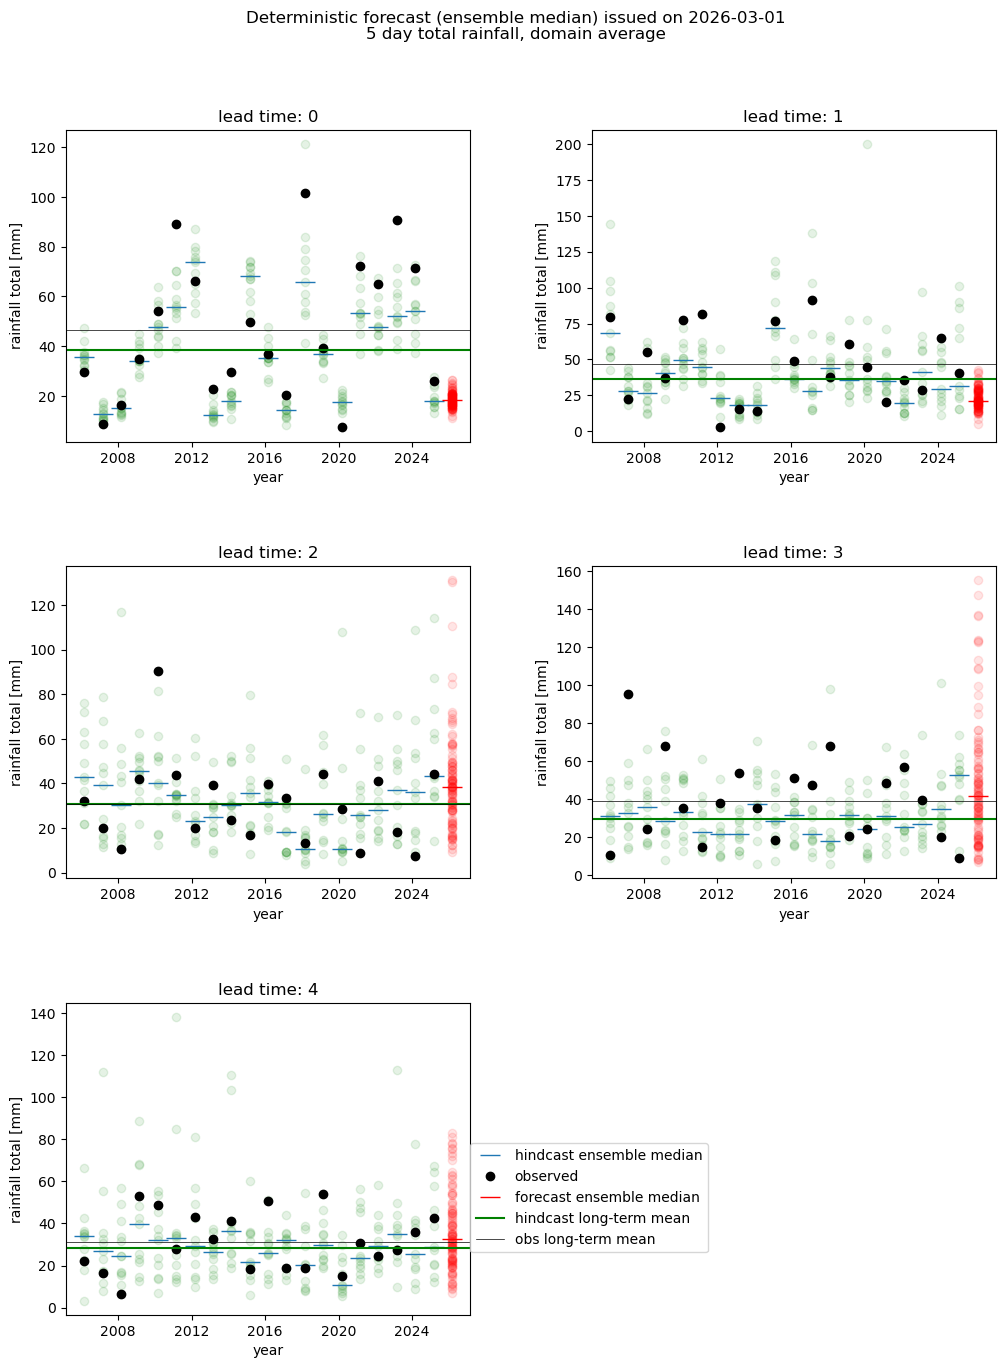

In [6]:
# plotting time series of hindcasts, forecast and obs, including ensemble members and median
#for illustration this is done for domain average

fig=plt.figure(figsize=(12,15))

for lead_time in range(5):
    pl=fig.add_subplot(3,2,lead_time+1)
    
    hcst=hindcast_lt.mean(["lat","lon"]).sel(lead_time=lead_time)
    obs=obs_lt.mean(["lat","lon"]).sel(lead_time=lead_time)
    fcst=forecast_lt.mean(["lat","lon"]).sel(lead_time=lead_time)
    
    for m in hcst.member:
        pl.plot(hcst.init_date,hcst.sel(member=m), "o", color="green", alpha=0.1)
        
    for m in fcst.member:
        cont=True
        pl.plot(fcst.init_date,fcst.sel(member=m), "o", color="red",alpha=0.1)
        
    pl.plot(hcst.init_date, hcst.median("member"), "_", ms=15, label="hindcast ensemble median")


    pl.plot(obs.init_date,obs, "o", color="black", label="observed")
    
    pl.plot(fcst.init_date,fcst.median("member"), "_", color="red", ms=15, label="forecast ensemble median")

    pl.axhline(hcst.median("member").mean(), label="hindcast long-term mean", color="green")
    pl.axhline(obs.mean(), label="obs long-term mean", color="black", lw=0.5)

    
    pl.set_title("lead time: {}".format(lead_time))
    pl.set_xlabel("year")
    pl.set_ylabel("rainfall total [mm]")

plt.legend(loc=(1,0.2))
plt.subplots_adjust(hspace=0.4, wspace=0.3, top=0.9)
plt.suptitle("Deterministic forecast (ensemble median) issued on {}\n{} day total rainfall, domain average".format(nominal_date, agg_window[:-1]))

plt.show()

Text(0.5, 0.98, 'Deterministic forecast (ensemble median) issued on 2026-03-01\n5 day total rainfall, domain average')

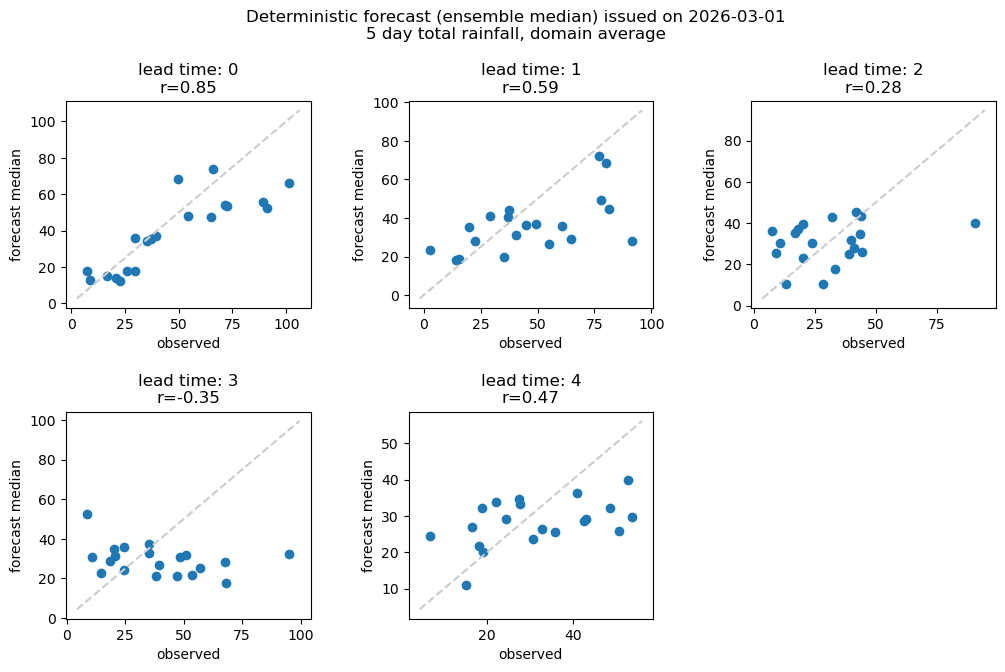

In [7]:
# plotting deterministic skill - i.e. correlation between obs and hindcast
# again, for simplicity - domain average

fig=plt.figure(figsize=(12,7))

for lead_time in range(5):
    pl=fig.add_subplot(2,3,lead_time+1)
    hcst=hindcast_lt.mean(["lat","lon"]).sel(lead_time=lead_time)
    obs=obs_lt.mean(["lat","lon"]).sel(lead_time=lead_time)    
    pl.plot(obs,hcst.median("member"),"o")
    r=np.round(np.corrcoef(obs.data,hcst.median("member").data)[0][1],2)
    pl.set_title("lead time: {}\nr={}".format(lead_time,r))
    pl.set_xlabel("observed")
    pl.set_ylabel("forecast median")
    lims = pl.get_xlim()
    pl.plot(lims, lims, "--", color="0.8")
        
plt.subplots_adjust(hspace=0.5, wspace=0.4, top=0.85)
plt.suptitle("Deterministic forecast (ensemble median) issued on {}\n{} day total rainfall, domain average".format(nominal_date, agg_window[:-1]))

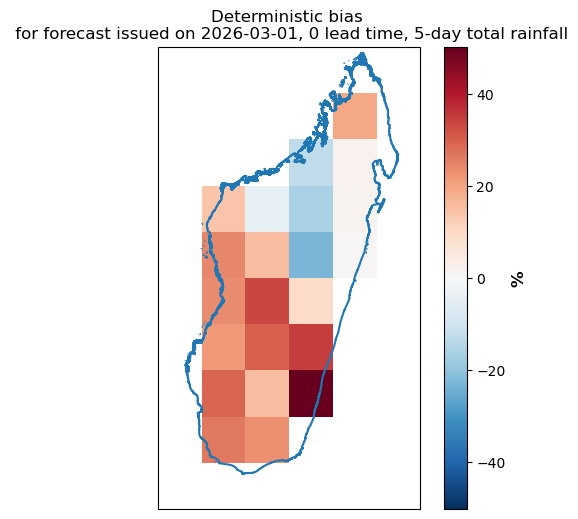

In [12]:
# plotting  deterministic bias - mean difference between obs and median of the hindcast ensemble
lead_time=0

ob=obs_lt.isel(lead_time=lead_time).mean("init_date")
hc=hindcast_lt.mean("member").isel(lead_time=lead_time).mean("init_date")
data2plot=((ob-hc)/ob)*100


overlay=gpd.read_file(domain_shape_file)
fig=plt.figure(figsize=(6,6))
pl=fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())
im=data2plot.plot(add_colorbar=False)
cbar = plt.colorbar(im)
cbar.set_label('%', size=12, weight='bold')

overlay.boundary.plot(ax=pl)
pl.set_title("Deterministic bias \n for forecast issued on {}, {} lead time, {}-day total rainfall".format(nominal_date, lead_time, agg_window[:-1]))
plt.show()




In [13]:
def biascorrection_meanvariance(forecast,hindcast,observed):

    #copy of original arrays to store results into
    hindcast_adjusted=hindcast.copy()
    forecast_adjusted=forecast.copy()
    
    for lead_time in hindcast.lead_time:
    
        hc=hindcast.sel(lead_time=lead_time)
        fc=forecast.sel(lead_time=lead_time)
        ob=observed.sel(lead_time=lead_time)
        
        hcvar=hc.var(["member","init_date"])
        
        #making sure no zeros
        hcvar = hcvar.where(hcvar != 0)
        variance_correction=ob.var(["init_date"])/hcvar
        
        #adjusting hindcast    
        hcadj=((hc-hc.mean(["member","init_date"]))*variance_correction)+ob.mean(["init_date"]) 
        hindcast_adjusted.loc[dict(lead_time=lead_time)]=hcadj.data
        
        fcadj=((fc-fc.mean(["member","init_date"]))*variance_correction)+ob.mean(["init_date"]) 
        forecast_adjusted.loc[dict(lead_time=lead_time)]=fcadj.data
    
    return forecast_adjusted, hindcast_adjusted

In [14]:


def qm_core(hc_1d, ob_1d, x_1d):
    # remove NaNs
    hc_1d = hc_1d[~np.isnan(hc_1d)]
    ob_1d = ob_1d[~np.isnan(ob_1d)]
    
    if len(hc_1d) == 0 or len(ob_1d) == 0:
        return np.full_like(x_1d, np.nan)

    hc_sorted = np.sort(hc_1d)
    ob_sorted = np.sort(ob_1d)
    
    q_hc = np.linspace(0, 1, len(hc_sorted))
    q_ob = np.linspace(0, 1, len(ob_sorted))
    
    p = np.interp(x_1d, hc_sorted, q_hc)
    return np.interp(p, q_ob, ob_sorted)


def biascorrection_qqmapping(forecast,hindcast,observed):

    #copy of original arrays to store results into
    hindcast_adjusted=hindcast.copy().transpose("lead_time", "lat", "lon", "init_date", "member")
    forecast_adjusted=forecast.copy().transpose("lead_time", "lat", "lon", "init_date", "member")
    
    for lead_time in hindcast.lead_time:

        hc=hindcast_adjusted.sel(lead_time=lead_time)
        fc=forecast_adjusted.sel(lead_time=lead_time)
        ob=observed.sel(lead_time=lead_time)
        

        hc_sample = (
            hc.stack(sample_hc=("member", "init_date"))
            .reset_index("sample_hc", drop=True)
        )
        
        fc_sample = (
            fc.stack(sample_fc=("member", "init_date"))
            .reset_index("sample_fc", drop=True)
        )
        
        ob_sample = (
            ob.stack(sample_ob=("init_date",))
            .reset_index("sample_ob", drop=True)
        )

        # transform hindcast
        hcadj=xr.apply_ufunc(
            qm_core,
            hc_sample,
            ob_sample,
            hc_sample,
            input_core_dims=[["sample_hc"], ["sample_ob"], ["sample_hc"]],
            output_core_dims=[["sample_hc"]],
            vectorize=True,
            dask="parallelized",
            output_dtypes=[hc.dtype],
            join="override",   
        )

        fcadj=xr.apply_ufunc(
            qm_core,
            hc_sample,
            ob_sample,
            fc_sample,
            input_core_dims=[["sample_hc"], ["sample_ob"], ["sample_fc"]],
            output_core_dims=[["sample_fc"]],
            vectorize=True,
            dask="parallelized",
            output_dtypes=[hc.dtype],
            join="override", 
        )
        print(hcadj.shape, hc.shape)
        hcadj = hcadj.data.reshape(hc.shape)
        fcadj = fcadj.data.reshape(fc.shape)
        
        hindcast_adjusted.loc[dict(lead_time=lead_time)]=hcadj.data
        forecast_adjusted.loc[dict(lead_time=lead_time)]=fcadj.data
    
    return forecast_adjusted, hindcast_adjusted

In [15]:
forecast_bc2,hindcast_bc2=biascorrection_qqmapping(forecast_lt,hindcast_lt,obs_lt)
forecast_bc1,hindcast_bc1=biascorrection_meanvariance(forecast_lt,hindcast_lt,obs_lt)


(10, 6, 220) (10, 6, 20, 11)
(10, 6, 220) (10, 6, 20, 11)
(10, 6, 220) (10, 6, 20, 11)
(10, 6, 220) (10, 6, 20, 11)
(10, 6, 220) (10, 6, 20, 11)


/home/piotr/mambaforge/envs/toolkit-test/lib/python3.11/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/home/piotr/mambaforge/envs/toolkit-test/lib/python3.11/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/home/piotr/mambaforge/envs/toolkit-test/lib/python3.11/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/home/piotr/mambaforge/envs/toolkit-test/lib/python3.11/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/home/piotr/mambaforge/envs/toolkit-test/lib/python3.11/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.

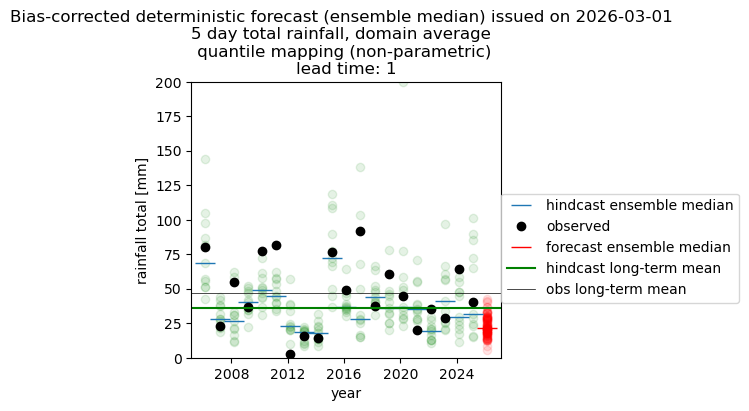

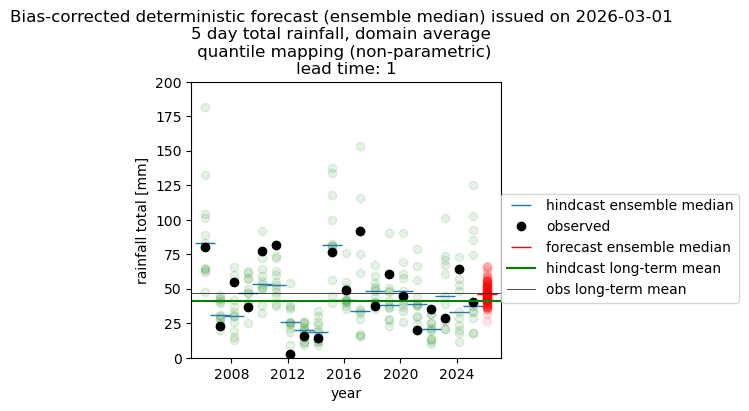

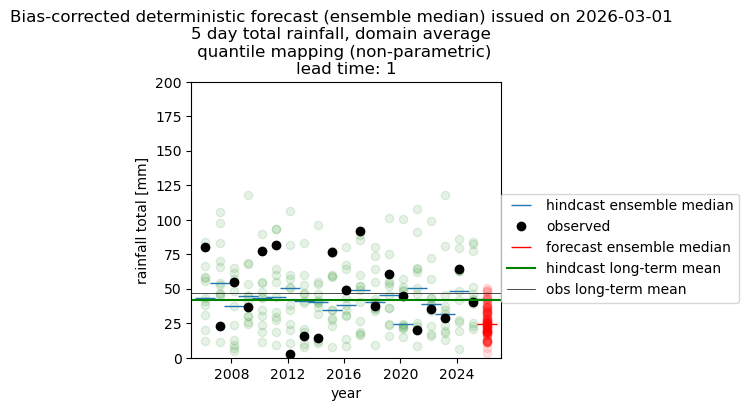

In [19]:
plot_forecasts2(hindcast_lt, forecast_lt, obs_lt)
plot_forecasts2(hindcast_bc1, forecast_bc1, obs_lt) 
plot_forecasts2(hindcast_bc2, forecast_bc2, obs_lt) 


In [17]:
# plotting time series of hindcasts, forecast and obs, including ensemble members and median
#for illustration this is done for domain average


def plot_forecasts(hindcast_bc,forecast_bc,obs_lt):
    fig=plt.figure(figsize=(12,15))
    
    for lead_time in range(5):
        pl=fig.add_subplot(3,2,lead_time+1)
        
        hcst=hindcast_bc.mean(["lat","lon"]).sel(lead_time=lead_time)
        obs=obs_lt.mean(["lat","lon"]).sel(lead_time=lead_time)
        fcst=forecast_bc.mean(["lat","lon"]).sel(lead_time=lead_time)
        
        for m in hcst.member:
            pl.plot(hcst.init_date,hcst.sel(member=m), "o", color="green", alpha=0.1)
            
        for m in fcst.member:
            cont=True
            pl.plot(fcst.init_date,fcst.sel(member=m), "o", color="red",alpha=0.1)
            
        pl.plot(hcst.init_date, hcst.median("member"), "_", ms=15, label="hindcast ensemble median")
    
    
        pl.plot(obs.init_date,obs, "o", color="black", label="observed")
        
        pl.plot(fcst.init_date,fcst.median("member"), "_", color="red", ms=15, label="forecast ensemble median")
    
        pl.axhline(hcst.median("member").mean(), label="hindcast long-term mean", color="green")
        pl.axhline(obs.mean(), label="obs long-term mean", color="black", lw=0.5)
    
        
        pl.set_title("lead time: {}".format(lead_time))
        pl.set_xlabel("year")
        pl.set_ylabel("rainfall total [mm]")
    
    plt.legend(loc=(1,0.2))
    plt.subplots_adjust(hspace=0.4, wspace=0.3, top=0.9)
    plt.suptitle("Bias-corrected deterministic forecast (ensemble median) issued on {}\n{} day total rainfall, domain average\n quantile mapping (non-parametric)".format(nominal_date, agg_window[:-1]))
    
    plt.show()


In [18]:
def plot_forecasts2(hindcast_bc,forecast_bc,obs_lt, lead_time=1):
    fig=plt.figure(figsize=(4,4))
    
    pl=fig.add_subplot(1,1,1)
    
    hcst=hindcast_bc.mean(["lat","lon"]).sel(lead_time=lead_time)
    obs=obs_lt.mean(["lat","lon"]).sel(lead_time=lead_time)
    fcst=forecast_bc.mean(["lat","lon"]).sel(lead_time=lead_time)
    
    for m in hcst.member:
        pl.plot(hcst.init_date,hcst.sel(member=m), "o", color="green", alpha=0.1)
        
    for m in fcst.member:
        cont=True
        pl.plot(fcst.init_date,fcst.sel(member=m), "o", color="red",alpha=0.1)
        
    pl.plot(hcst.init_date, hcst.median("member"), "_", ms=15, label="hindcast ensemble median")


    pl.plot(obs.init_date,obs, "o", color="black", label="observed")
    
    pl.plot(fcst.init_date,fcst.median("member"), "_", color="red", ms=15, label="forecast ensemble median")

    pl.axhline(hcst.median("member").mean(), label="hindcast long-term mean", color="green")
    pl.axhline(obs.mean(), label="obs long-term mean", color="black", lw=0.5)

    pl.set_ylim(0,200)
    pl.set_title("lead time: {}".format(lead_time))
    pl.set_xlabel("year")
    pl.set_ylabel("rainfall total [mm]")
    
    plt.legend(loc=(1,0.2))
    plt.subplots_adjust(hspace=0.4, wspace=0.3, top=0.8)
    plt.suptitle("Bias-corrected deterministic forecast (ensemble median) issued on {}\n{} day total rainfall, domain average\n quantile mapping (non-parametric)".format(nominal_date, agg_window[:-1]))
    
    plt.show()
